In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

This [dataset](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope) contains measurements taken from an atmospheric telescope. Its purpose is to distinguish between two types of particles hitting the atmosphere: gamma rays (the signal you want to find) and hadron showers (the background noise created by cosmic rays).

When particles hit the atmosphere, they create a shower of secondary particles that emit faint light. A ground-based telescope captures these light patterns. The data provides 10 numerical features (like the length, width, and angle of the light "ellipse" seen in the camera) for 19,020 recorded events. Task is to look at these features and classify each event as either "g" (gamma) or "h" (hadron).

It is a binary classification problem. Train a model to draw a decision boundary that separates two groups. If you don't classify, your telescope data is just a massive blur of noise. You cannot see the black hole or the cosmic event you are studying because the "noise" (hadron showers) is overwhelming the "signal" (gamma rays). By training a computer to classify the images correctly, you act as a filter. You throw away the 99% of junk data (noise) so that you are left with only the high-quality, scientifically significant gamma ray data.


### But why machine learning here?
1. You feed the model thousands of examples where you already know the answer (this is your training set).
2. The model starts by making random guesses about the relationship between the 10 features (length, width, etc.) and the result (gamma vs. hadron).
3. It calculates its error rate (Loss Function). It sees how far off its guesses were from the real answers.
4. It uses math (specifically calculus, through a process called Gradient Descent) to nudge its internal "weights" to reduce that error.

It repeats this thousands of times. Eventually, the model builds a complex, multidimensional map that separates the two classes much better than any human-written rule could.

Rules-based: "If length > 10, then Noise." (Very limited, high error).

Machine Learning: "If [length * 0.5 + width * -0.2 + alpha * 0.1...] > Threshold, then Signal." (Highly accurate, captures complex patterns).



In [23]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.sample(5)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
17737,18.0358,8.7369,2.4388,0.5838,0.2898,-23.9383,-8.4160,-5.6080,83.4883,162.4455,h
17068,83.0709,10.6598,2.5906,0.2884,0.1440,44.5695,-63.4663,-2.3165,82.4601,253.8346,h
1411,23.8725,11.8221,2.3444,0.6697,0.3552,28.0330,-8.6348,-8.9284,9.0270,159.3820,g
4163,56.6139,26.1253,3.3259,0.1667,0.0862,0.5887,48.7686,-20.3598,9.8420,203.8090,g
12957,41.1880,8.7842,2.8172,0.5072,0.3191,12.6751,30.7532,-2.4186,15.6484,200.2980,h


We got 10 features and target value.
In machine learning, features are the individual, measurable properties or characteristics of your data that the model uses to make a prediction. The performance of a machine learning model is often more dependent on the quality of your features than the type of algorithm you choose. This is often called **Feature Engineering**.

This is a **supervised machine learning problem** because we have labels for each row. The model’s goal is to learn the mathematical mapping function that connects the input features to the known target.
* Inputs ($X$): The 10 numerical features (fLength, fWidth, fSize, etc.) for each event.
* Target ($y$): The label "g" (gamma) or "h" (hadron) that acts as the "answer key."

Or spam detection is another real world example. You feed an algorithm thousands of emails already labeled as "spam" or "not spam." The algorithm learns the patterns of words or metadata that distinguish the two. Because it is given the labels, it can learn to predict the category for future, unlabeled emails.

In [24]:
df["class"].unique()

array(['g', 'h'], dtype=object)

Computers, machine learning libraries do not understand "g" or "h." They only understand numbers.
Machine learning models calculate weights based on gradients. You cannot calculate the "gradient" of a "g." You can, however, calculate the "gradient" of a 1 or a 0.

In [25]:
df["class"] = (df["class"] == "g").astype(int)

`(df["class"] == "g")` > True/False mask. If the value is "g", it writes True. If it is "h", it writes False.

`.astype(int)` > convert those boolean values into the integers 1 and 0.

In [26]:
df.sample(5)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
13876,103.8751,43.5467,3.5540,0.2919,0.1803,13.2961,53.9875,-32.5059,17.1784,346.1485,0
14969,41.9913,17.9165,2.7508,0.3411,0.1601,-76.7312,41.1898,-4.3532,3.9992,280.8530,0
16771,134.2851,71.4363,3.5196,0.1470,0.1033,-11.1557,-40.8617,-31.9132,44.4854,371.8306,0
10933,25.1239,12.2252,2.4091,0.5419,0.3177,15.0000,10.9236,-11.8951,22.2320,165.1690,1
18921,31.1411,13.9297,2.6121,0.5194,0.3173,4.7860,23.0934,-5.2272,20.2988,244.3127,0


One-hot encoding is a method for converting categorical data into a numeric format that machine learning models can process without making incorrect assumptions about the data.
Imagine you have a "Color" column with these values:
* Red
* Blue
* Green

If you simply map them to numbers like 1, 2, and 3, you create a false relationship. A model might assume that "Green (3)" is "greater than" or "three times" "Red (1)." This is a mathematical error, as there is no numerical order for colors. One-hot encoding creates a new column for every unique category. It uses only 1s and 0s to indicate the presence of a category.
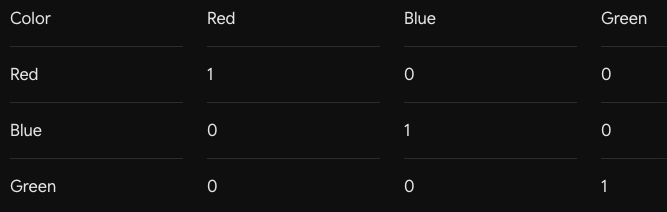

Supervised learning splits into two main tasks based on what the "answer" (the target) looks like: **Classification** and **Regression**.

### Classification (Categorical Targets)
The Goal: Predict a discrete group.
Examples:
* Binary (2 groups): Yes/No, Spam/Not Spam, Gamma/Hadron (telescope data).
* Multiclass (3+ groups): Predicting the species of a flower, identifying a digit (0–9) in an image, or classifying foods.

### Regression (Continuous Targets)
Use regression when the target variable is a quantity—a number that can fall anywhere on a scale. You are trying to predict a specific value.
Examples:
* House Prices: Predicting the exact price of a property based on square footage, location, and age.
* Temperature


## Phase 1: How the model learns

*   Forward Pass (The Guess): The model takes your features (the 10 telescope measurements) and performs a series of mathematical calculations (multiplying features by "weights"). It outputs a probability—for example, "I am 70% sure this is a gamma ray."

* Calculate Loss (The Mistake): The model compares its guess to the actual label (0 or 1). If the model predicted 0.7 but the real answer was 1, the "Loss" is high. If it predicted 0.9, the "Loss" is low.

* Backpropagation (The Correction): This is the core of learning. The model looks at its internal weights and nudges them using calculus (Gradient Descent). It asks: "If I change this specific weight by a tiny amount, does the error go down?" It repeats this thousands of times across the entire dataset until it reaches the lowest possible error.

## Phase 2: How you verify it is learning
You cannot judge learning by looking at how well it performs on the data it already saw.
To verify, you use Model Validation:

* Train/Test Split: You hide 20% of your data (the "Test Set") from the model entirely. The model only learns from the 80% (the "Training Set").

* Tracking the Curves: You plot the error rate (Loss) over time (epochs).

* Good Learning: Both the training error and the testing error decrease together.

* Overfitting: The training error keeps dropping, but the testing error starts to increase. This means the model is "memorizing" the training data instead of learning the physics of the telescope.

* Underfitting: Both errors stay high. The model is too simple to grasp the patterns.


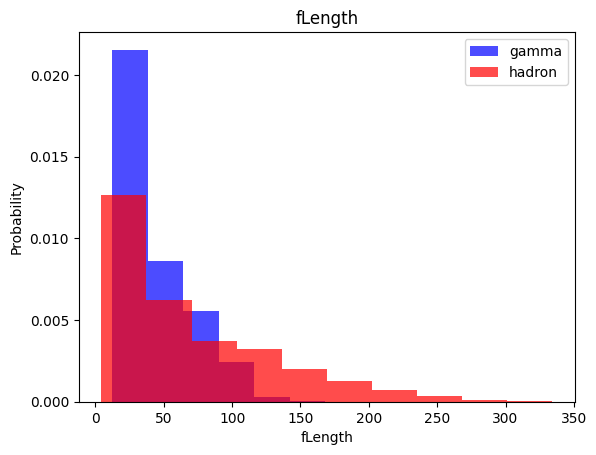

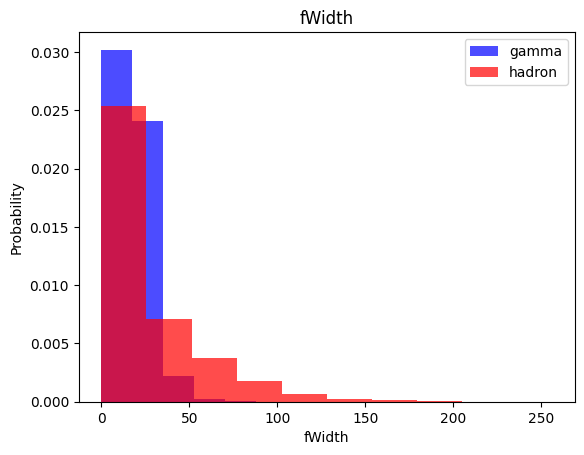

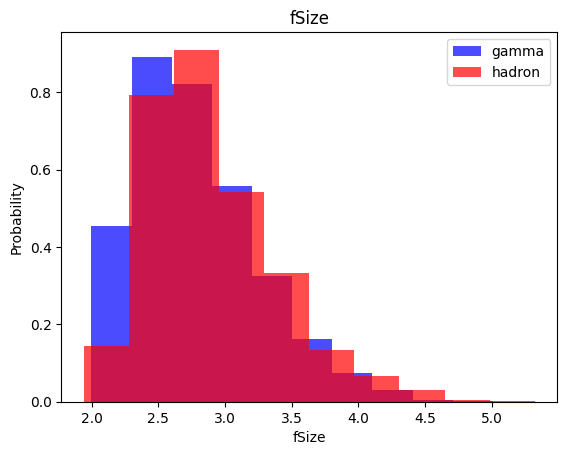

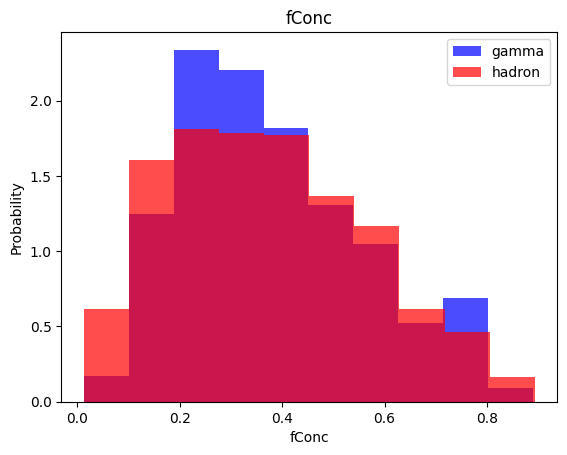

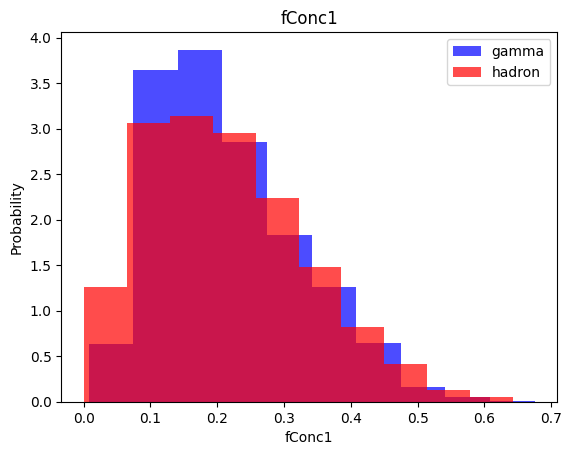

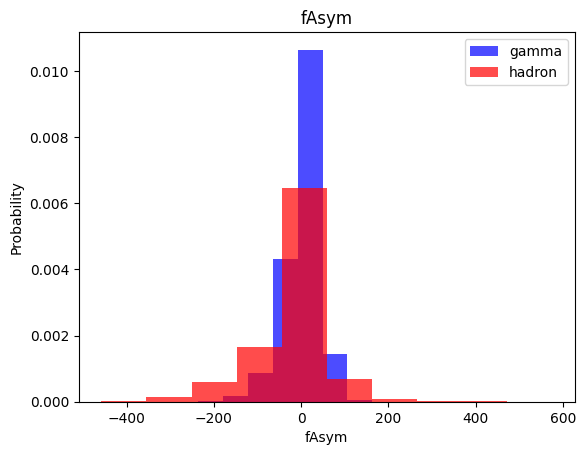

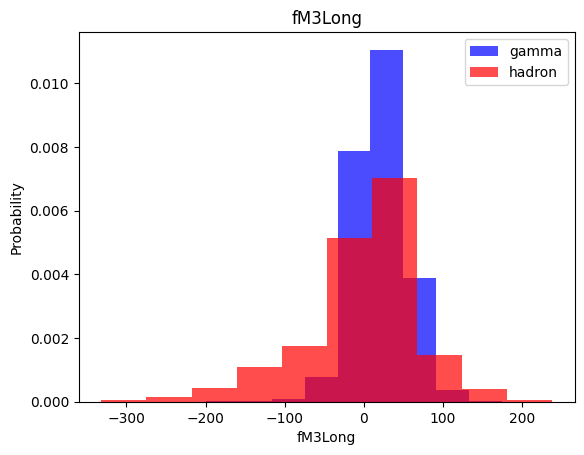

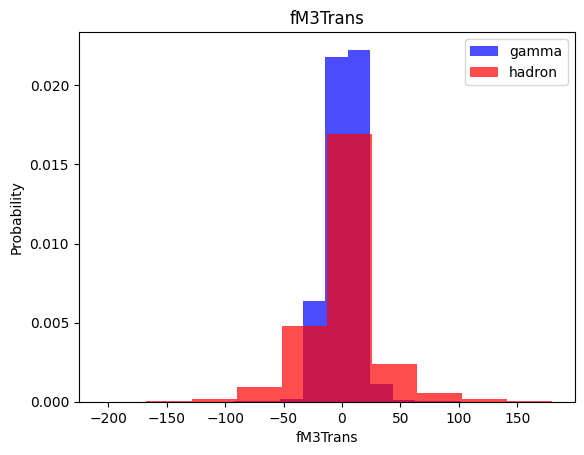

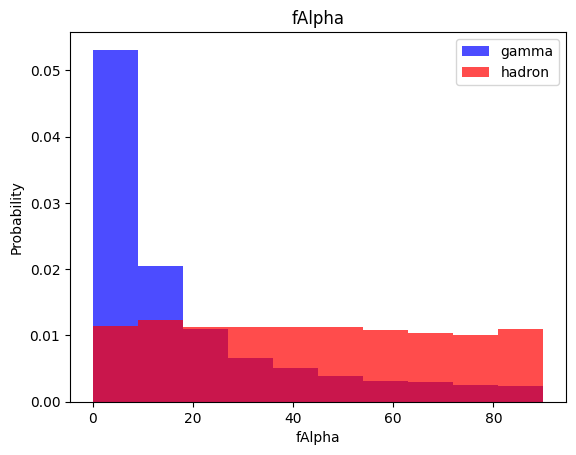

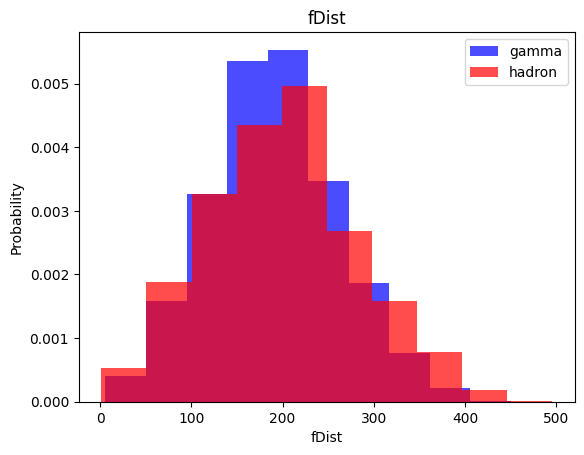

In [27]:
# Exploratory Data Analysis (EDA) - visualize how well each of your features separates "gamma" (signal) from "hadron" (noise).
for label in cols[:-1]: #every column except the last one
  plt.hist(df[df["class"]==1][label], color='blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color='red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

* The Overlap: Look at where the blue (gamma) and red (hadron) bars overlap.
If the bars are mostly on top of each other, that feature is "weak." It doesn't help the computer tell the difference between the two particles.
If the two colors are clearly separated (e.g., all the blue is on the left and all the red is on the right), that feature is "strong." It is a powerful indicator that the model can easily use to classify the particle.

* The Tails: Look at the extreme ends of the bars. Sometimes a feature might overlap in the middle but have unique "tails" where only one class exists. That is also a useful pattern for a model to learn.

If you see that your features have very different ranges (e.g., one goes from 0 to 1, another from 100 to 1000), you will know that you must scale your data (using StandardScaler) before training, or the model will ignore the smaller features.

## Loss Function
A loss function is the mathematical bridge between your model’s prediction and reality. It provides a numerical score a "penalty" for how wrong the model is.
### L1 Loss (Mean Absolute Error)
L1 loss is the sum of the absolute differences between the predictions and the actual values.
L1 is less sensitive to outliers. If you have a few extreme data points that are way off, L1 ignores them more gracefully than L2, making the model more stable. Use this when your data is "noisy" or contains many extreme, unreliable values (outliers) that you don't want to skew your model.

### L2 Loss (Mean Squared Error)
L2 loss is the sum of the squares of the differences between the predictions and the actual values.

The Math: $\text{Loss} = (y - \hat{y})^2$

Because you square the difference, large errors are punished exponentially more than small ones. L2 forces the model to work extremely hard to fix large errors. It prioritizes getting the "big" mistakes right over fine-tuning small, insignificant ones. Use this when you want your model to be highly accurate on every single point, as it ensures no single prediction is wildly wrong.

Why not L2 but L1: L2 squares the error, it acts like a magnifying glass for outliers. The model will "panic" and shift its entire logic to try to satisfy that one extreme outlier, resulting in a model that performs poorly on all the normal data.

# Train, validation, test datasets

* Training Set (e.g., 70%): The data the model uses to learn its weights.

* Validation Set (e.g., 15%): The data you use to evaluate your experiments. You use this to pick the best model settings. You adjust your model based on how it performs here. Overfitting happens when a model learns the "noise" in the training data rather than the "signal." The validation set helps you stop training the moment the model stops generalizing and starts memorizing.

* Test Set (e.g., 15%): The "vault." You do not look at this data or use it to tune anything until the very end. It represents completely unseen, real-world data.

Train the model on the Training set. Check performance on the Validation set. Tweak your settings based on the Validation score. Repeat steps 1-3 until you are happy with the Validation score. Run the model on the Test set exactly one time to see how it will truly perform.

In [28]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


`df.sample(frac=1)` > Before splitting, you need to mix the data.

`np.split(...)`  >  NumPy function that cuts an array into pieces at specific index points.

`[int(0.6*len(df)), int(0.8*len(df))]` >  First cut at 60%: `int(0.6*len(df))` creates the boundary between Training and Validation. Second cut at 80%: i`nt(0.8*len(df))` creates the boundary between Validation and Testing.

- train: Rows from 0 to 60%. (60% of data)

- valid: Rows from 60% to 80%. (20% of data)

- test: Rows from 80% to 100%. (20% of data)

In [29]:
print(len(train[train["class"]==1]))
print(len(train[train["class"]==0]))
#imbalance

7369
4043


In [30]:
def scale_dataset(dataframe, oversample=False):
  X = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

### Separating Data ($X$ and $y$)
It splits the table into two parts. X contains all the columns except the last one (features/inputs). y contains only the last column (the "class" target). Using .values converts these from a pandas DataFrame into a NumPy array, which is the required format for most math operations.

### Standard Scaling
If one feature (like fSize) has values in the thousands and another (like fAlpha) has values between 0 and 1, the model will mistakenly think the larger numbers are "more important."
- `StandardScaler` shifts the data so the mean is 0 and the standard deviation is 1. It forces all features to exist on the same scale so the model evaluates them fairly.

### Handling Imbalance (Oversampling)
If you have 12,000 gammas but only 6,000 hadrons, the model will become biased toward predicting "gamma" because it sees more of them.
* RandomOverSampler detects the minority class and creates duplicate examples until the numbers match. This "balances" the training set so the model doesn't ignore the less common particle.

`data = np.hstack((X, np.reshape(y, (-1, 1))))`
stacks the processed features (X) and the target labels (y) back into a single matrix. The reshape part ensures the labels align vertically with the features.

In [31]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

Ensure that your features are normalized and that your training data is balanced.

**Why apply it this way**

**Oversampling is for Training ONLY**: Notice that `oversample=True` is only used for the train dataset.

The goal of a test set is to represent the real world. In the real world, gamma rays and hadrons appear in a specific ratio. If you artificially duplicate your test data to make it balanced, you are testing on "fake" data, and your performance metrics will be completely wrong.


The Result
After running these we have six clean, numeric variables ready for machine learning model:

- X_train, y_train: The balanced, scaled features and labels used to teach the model.

- X_valid, y_valid: The real-world ratio, scaled features and labels used to tune your settings.

- X_test, y_test: The real-world ratio, scaled features and labels used for the final, unbiased "exam."

# kNN (k-Nearest Neighbors)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

Imagine you have a plot of data points representing gamma rays (blue) and hadrons (red). When you introduce a new, unknown data point, kNN identifies the "k" closest neighbors to that point based on distance (usually Euclidean distance).

It then looks at the classes of those $k$ neighbors. If the majority of the neighbors are "gamma," the model labels the new point as "gamma." If the majority are "hadron," it labels it as "hadron."

- "k" is a parameter you choose. If $k=5$, the model looks at the 5 nearest points to make a decision.

- No "Training" phase: kNN is a "lazy" learner. It doesn't build a complex mathematical model. It simply memorizes the training data and performs a distance calculation every time you ask it to make a prediction.

In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
y_pred = knn_model.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.72      0.74      1360
           1       0.85      0.86      0.86      2444

    accuracy                           0.81      3804
   macro avg       0.80      0.79      0.80      3804
weighted avg       0.81      0.81      0.81      3804



kNN relies entirely on distance. If you do not use your `StandardScaler`, features with large numerical values will dominate the "distance" calculation. If `fSize` is 10,000 and `fAlpha` is 0.5, the model will essentially ignore fAlpha because its contribution to the distance is tiny. Always ensure you are passing the scaled data into this model.

- Precision (The "Trust" score): When the model predicts a specific class, how often is it right? This means when your model says "This is a gamma ray," it is correct 85% of the time.

- Recall (The "Catch-all" score): Out of all the actual events of a specific class, how many did the model find? model successfully found 87% of all the actual gamma rays in the test set.

- f1-score: This is the balance between Precision and Recall.


model is better at finding Gammas: Notice that all the scores for Class 1 (0.85, 0.87, 0.86) are significantly higher than the scores for Class 0 (0.74, 0.72, 0.73). The model is finding and identifying gamma rays more accurately than it identifies background hadrons.

# Naive Bayes

In [36]:
from sklearn.naive_bayes import GaussianNB

Naive Bayes uses probability and statistics to make decisions. It is based on Bayes' Theorem. It works by answering this question: "*Given that this particle has a length of 45mm and a width of 12mm, what is the probability it is a gamma ray versus a hadron?*"
* "Gaussian" Part: The model looks at your features and calculates the average (mean) and spread (variance) for both classes. It assumes the data follows a normal bell curve (a Gaussian distribution). If a new particle's measurements fall right in the middle of the "gamma" bell curve, it assigns a high probability to gamma.

* "Naive" Part: The algorithm is called "naive" because it makes a massive assumption: it assumes that every feature is completely independent of the others. For example, it assumes that the length of a light shower has absolutely nothing to do with its width. In nature, this is rarely true, but the algorithm performs remarkably well anyway and is incredibly fast.


In [37]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

Create an empty model container. Then the model calculates the mean and standard deviation for each of our 10 features, separating the math for gammas ($1$) and hadrons ($0$).
- This step runs much faster than kNN because it only needs to calculate a few summary statistics rather than memorizing thousands of points.

In [38]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.40      0.51      1360
           1       0.73      0.90      0.81      2444

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



Overall accuracy dropped from 0.81 (kNN) down to 0.72 (Naive Bayes). This means Naive Bayes is guessing incorrectly on 28% of the test data.

**Class 0 (Hadrons):**
- Recall is 0.41. This is the critical failure point. It means the model only successfully caught 41% of the actual hadrons. It missed 59% of them, misclassifying them as gamma rays instead.
- F1-Score is 0.51: The model's ability to identify hadrons is barely better than flipping a coin.

**Class 1 (Gammas):**
- Recall is 0.89. The model caught 89% of all gamma rays.
- The Reality: The model achieved this high recall simply by being incredibly aggressive. It is labeling almost everything as a gamma ray. Because it throws the "gamma" label at so many points, its precision dropped to 0.74 (meaning when it says gamma, it is wrong 26% of the time).

### Why did Naive Bayes perform worse than kNN?
Naive Bayes assumes all our 10 of telescope features are completely independent of each other. In a real physics experiment like the MAGIC telescope, features are heavily dependent on each other. A longer light shower is naturally going to be wider and have a larger total size.

Because Naive Bayes ignores these relationships, it lost critical context that the kNN model was able to preserve through simple distance calculations.

# Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

Despite having "Regression" in its name, this is actually a powerful linear model used strictly for Classification.
Logistic Regression works by finding a straight line (or a flat plane in higher dimensions) that best splits your two classes.

- The Linear Part: It calculates a weighted sum of our 10 features, similar to standard linear regression.

- The S-Curve (Sigmoid Function): Instead of outputting a continuous number, it squeezes that raw number through a mathematical function called the Sigmoid function. This forces the output to be a value strictly between 0 and 1, which represents a probability.

If the model processes a particle's features and outputs 0.85, it means there is an 85% probability that the particle is a gamma ray. By default, if the probability is 0.50 or higher, the model classifies it as a 1. If it is lower, it classifies it as a 0.

In [40]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

The model assigns a weight ($w$) to every one of our 10 features. For every event in our telescope data, it calculates a total score:

$$Score = (w_1 \cdot \text{length}) + (w_2 \cdot \text{width}) + ... + \text{bias}$$

This score can be any number massive and positive, or massive and negative. A very high positive score means the model is leaning heavily toward "Gamma," while a very low negative score means it's leaning toward "Hadron."

**Sigmoid function**

($S(z) = \frac{1}{1 + e^{-z}}$)

is a mathematical "squeezer." It takes that raw score and maps it onto a strict scale between 0 and 1.
- If the score is 0, the Sigmoid output is exactly 0.5 (a 50/50 toss-up).
- If the score is a large positive number, the Sigmoid output gets closer and closer to 1.0.
- If the score is a large negative number, the Sigmoid output gets closer and closer to 0.0.

Once the Sigmoid function gives that probability (e.g., 0.85), the model applies a threshold to make a final classification:
- Output $\ge$ 0.5: Classify as 1 (Gamma).
- Output < 0.5: Classify as 0 (Hadron).

The "S-shape" isn't about the shape of our telescope data in physical space; it's the shape of the probability curve. It represents the transition from "definitely a hadron" to "definitely a gamma."

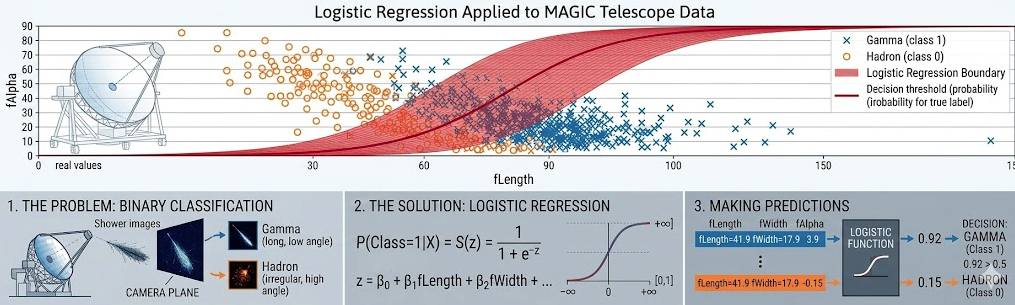

In [21]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.73      0.70      1333
           1       0.85      0.81      0.83      2471

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.79      0.78      0.79      3804



Overall accuracy is 78%. This is a solid improvement over Naive Bayes (72%).
However, it still falls short of our kNN model (82%).
Class 1 - Precision (0.85): When the model says "Gamma," you can trust it 85% of the time. This matches your kNN model's precision exactly.

Logistic Regression looks at the combinations of your features rather than treating them as isolated islands. Since your features are correlated (like length and width), this model captured that shared information.

kNN won because it doesn't care about straight lines; it just looks at local neighborhoods.

In [42]:
# df.to_csv("modified_magic_data.csv", index=False) > if you want to download your dataset with normalization applied

# Support Vector Machine (SVM)

A Support Vector Machine is designed to find a boundary that separates our classes with the widest possible safety margin.

- The Margin Maximize Principle: Instead of just drawing any line that separates gammas from hadrons, SVM looks for the points closest to the opposing class (these critical points are called Support Vectors). It draws a decision boundary right down the middle to maximize the distance (the margin) between these support vectors.

- The "Kernel Trick": By default, scikit-learn uses an RBF (Radial Basis Function) kernel for SVM. The RBF kernel mathematically projects our 10-dimensional data into a much higher-dimensional space where complex, intertwined clusters suddenly become cleanly separable by a flat plane.

When it projects back down into our original 10 features, that boundary looks like a highly flexible, non-linear curved surface that wraps perfectly around the data pockets.

In [43]:
from sklearn.svm import SVC

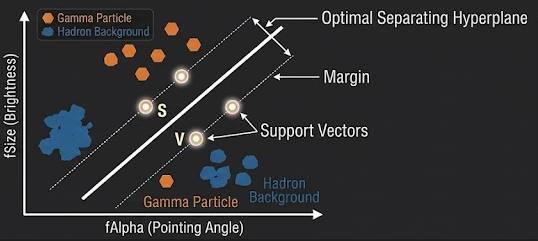

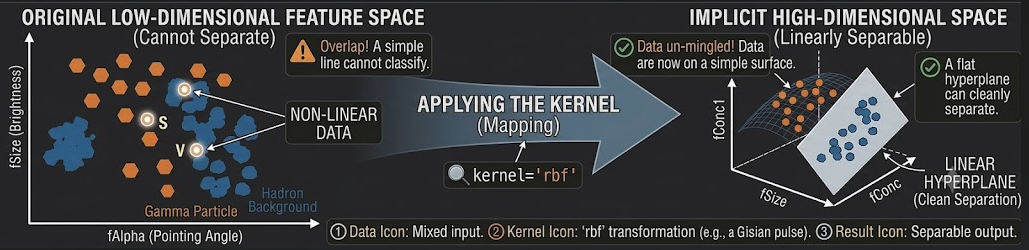

SVM is not considered a robust algorithm for three primary reasons:

Extreme Sensitivity to Noise and Outliers

+

High Vulnerability to Overfitting (Kernel Hyperparameters)

+

SVM does not scale well to large volumes of data. The training time complexity for an SVM is generally between $O(n^2)$ and $O(n^3)$, where $n$ is the number of rows in your dataset.

If your dataset grows from a few thousand rows to hundreds of thousands, the algorithm becomes computationally expensive and slow to train, making it fragile for production pipelines with streaming data.

In [44]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [45]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1360
           1       0.89      0.89      0.89      2444

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



86% accuracy means the model is handling the complex physics signatures from the telescope exceptionally well.
- Class 0 (Hadrons): Both precision (0.80) and recall (0.81) are balanced. The model is no longer overly biased.

- Class 1 (Gammas): Precision (0.89) and recall (0.89) are remarkably high. This means your telescope system is now highly reliable at pinpointing actual gamma ray events without capturing massive amounts of background noise.

# Deep Neural Network

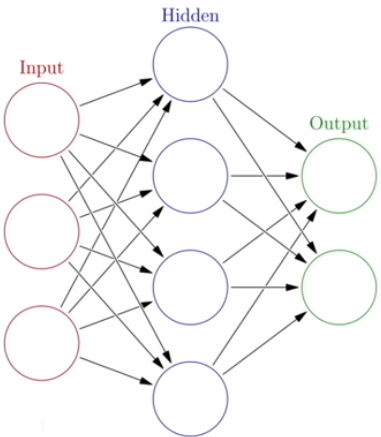

Architecture inspired by the structure of the human brain. Unlike our previous models, a neural network does not try to fit a single line (like Logistic Regression) or measure distances (like kNN). Instead, it passes data through multiple layers of mathematical operations to learn abstract features on its own.

A neural network is built from layers of interconnected nodes called **neurons**. It consists of three main parts:

1. Input Layer: This layer receives your raw data. If you have 10 telescope measurements, your input layer will have exactly 10 nodes-one for each feature.

2. Hidden Layers: This is where the processing occurs. A network can have one or dozens of hidden layers (which is why it is called "deep" learning). The neurons in these layers combine features in complicated ways to detect patterns that a human or a simpler algorithm would miss.

3. Output Layer: This layer delivers the final prediction.

To understand the whole network, you only need to understand what happens inside a single neuron. It performs a simple calculation in two steps:
### Step 1: The Weighted Sum
The neuron takes all inputs from the previous layer, multiplies each by a specific weight ($w$), adds them together, and adds a constant value called a bias ($b$).$$z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + ... + b$$

Weights determine how much importance a neuron places on a specific input. The bias ensures the neuron only activates when the total signal crosses a certain threshold.

### Step 2: The Activation Function
If a neural network only calculated weighted sums, it would just be a giant chain of linear equations meaning it could still only draw straight lines. To fix this, the output $z$ is passed through an Activation Function.

The activation function introduces non linearity into the network. The most common choice for hidden layers is ReLU (Rectified Linear Unit), which simply outputs 0 if the input is negative, and outputs the raw number if it is positive

($f(x) = \max(0, x)$).

For the final output layer, it uses the Sigmoid function to turn the result into a clean probability.

First, inputs (like telescope features $x_1, x_2, x_3$) are multiplied by weights, summed, and then combined with a single number called a Bias (b). The result is just a raw number, which can be anything.  The activation function is applied immediately to that raw number. It acts as a "gatekeeper" that transforms the $z$ score.
Because functions like ReLU introduce bends and thresholds (turning negative numbers to zero, etc.), the network can combine many non-linearities.

## How It Learns (The Feedback Loop)
When you first initialize a neural network, all the weights and biases are set to random numbers. The model is completely guessing. It learns through a continuous loop:

1. Forward Propagation: The 10 features enter the input layer, travel through the hidden layers, get transformed by activation functions, and output a prediction.

2. Loss Calculation: The network calculates its error using a loss function (like Binary Cross-Entropy).

3. Backpropagation: The network passes the error backward through the layers using calculus (the chain rule). It calculates exactly how much each weight contributed to the mistake and adjusts them using an optimizer (like Adam or Stochastic Gradient Descent) to reduce the error for the next round.

$$\text{New Weight} = \text{Old Weight} - (\text{Learning Rate} \times \text{Blame Score})$$

Learning Rate is just a tiny multiplier (like 0.001) that ensures the network makes small, controlled adjustments rather than overcorrecting wildly.

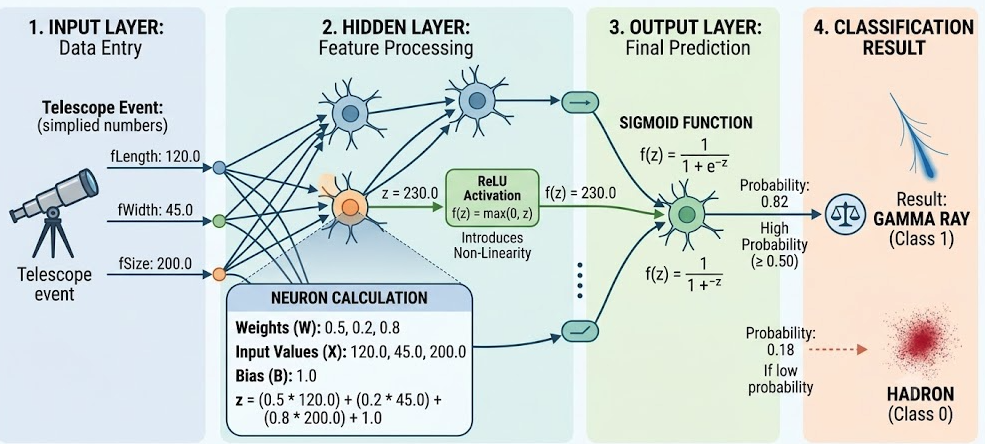

In [46]:
import tensorflow as tf

TensorFlow and PyTorch are the two dominant open-source deep learning frameworks in the industry. They are massive math libraries optimized for matrix operations (tensors) that utilize GPUs to accelerate computation.

They provide the foundational building blocks required to design, train, and deploy neural networks without writing raw calculus or CUDA GPU code from scratch.

Other alternatives:

- JAX (by Google): A high-performance framework in research. It focuses on composable transformations of Python and NumPy code, though it lacks the out-of-the-box high-level deployment tools of TensorFlow.

- Legacy Frameworks: Caffe, Theano, and MXNet were foundational historical frameworks but have largely been phased out or superseded by PyTorch and TensorFlow.

PyTorch vs TensorFlow difference lies in how these frameworks construct the mathematical graph that routes data through the neural network.

- PyTorch: Dynamic Graphs  - builds its execution graph on the fly as the code runs

- TensorFlow: Historically Static (Now Hybrid) - you had to define the entire network structure first, compile it, and then feed data into it via a closed session.

Use Cases: Which One to Use?

- Choose PyTorch if you are doing cutting-edge research or custom architecture design. If you need to modify the loss calculation mid-training or invent a new type of attention layer. You want a clean debugging experience. You are working heavily with LLMs or Generative AI.

- Choose TensorFlow if you need rapid prototyping of standard models.

In [47]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  plt.show()

When a model trains, Keras keeps a log of its performance at every step inside an object called history. This function takes that data and splits it into two diagnostic plots side-by-side.

`fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))`

- Left Plot (ax1): Loss vs. Validation Loss. This tracks the error. You want both lines to slope downward. If the training loss line keeps dropping but the validation loss line starts curving upward, it means your model is overfitting.

- Right Plot (ax2): Accuracy vs. Validation Accuracy. This tracks the percentage of correct guesses. You want to see these lines rise and plateau.

In [48]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
  history = nn_model.fit(
    X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0
  )

  return nn_model, history

- `tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,))`: This is our input and first hidden layer. input_shape=(10,) tells the network to expect our 10 specific telescope features. It uses the non-linear ReLU activation gate to learn complex boundaries.

- `tf.keras.layers.Dropout(dropout_prob)`: This is a regularization technique. During training, it randomly "turns off" a percentage of neurons in this layer on every step. This forces the remaining neurons to learn independent patterns so the network doesn't become overly reliant on a single dominant pathway. This directly targets the overfitting problem.

- `tf.keras.layers.Dense(1, activation='sigmoid')`: The output layer. It contains a single neuron wrapped in a Sigmoid function, converting the internal signals into a final probability between 0 and 1 (Gamma vs. Hadron).

- `Adam` Optimizer: This runs the backpropagation loop, dynamically adjusting the step size for every weight.

- `Binary Crossentropy`: The mathematical loss function designed specifically for binary classification.

The script multiplies these combinations out: $3 \times 2 \times 3 \times 3 = 54$. It will run the entire training process 54 separate times to find the sweet spot.

Instead of selecting the model with the highest training accuracy, the script strictly looks at Validation Loss (`val_loss`). Loss is a much more granular metric than accuracy because it accounts for how confident the model's predictions are. The loop updates and saves only the model that achieves the lowest overall error on unseen validation data.

16 nodes, dropout 0, lr 0.01, batch size 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


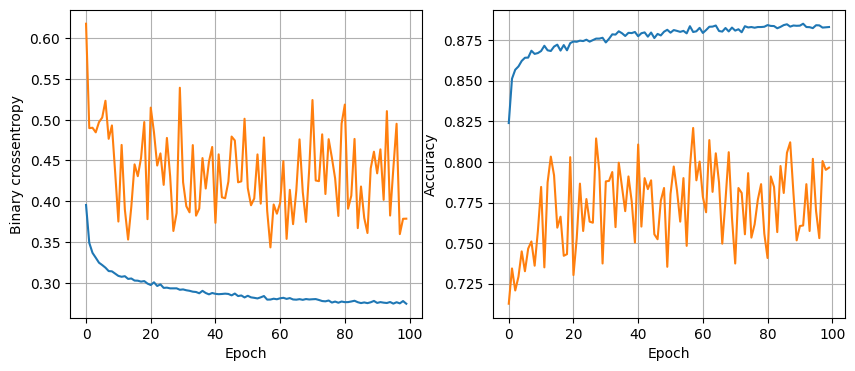

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8722 - loss: 0.3262
16 nodes, dropout 0, lr 0.01, batch size 64


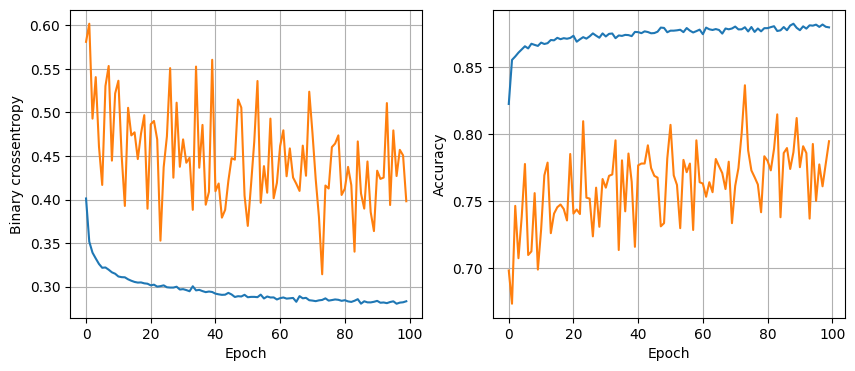

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3455
16 nodes, dropout 0, lr 0.01, batch size 128


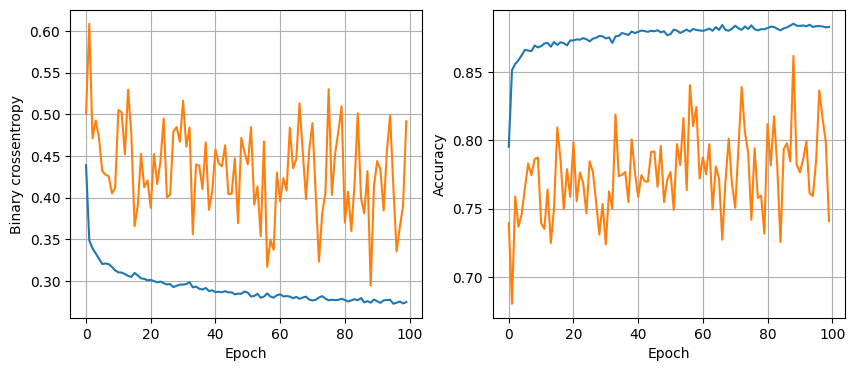

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8649 - loss: 0.3356
16 nodes, dropout 0, lr 0.005, batch size 32


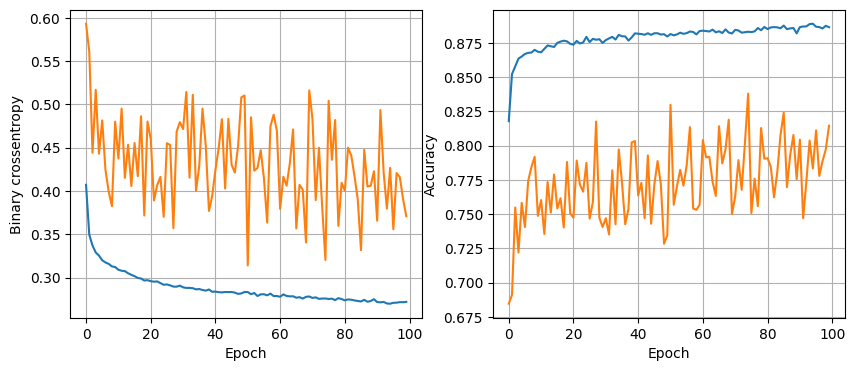

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8644 - loss: 0.3410
16 nodes, dropout 0, lr 0.005, batch size 64


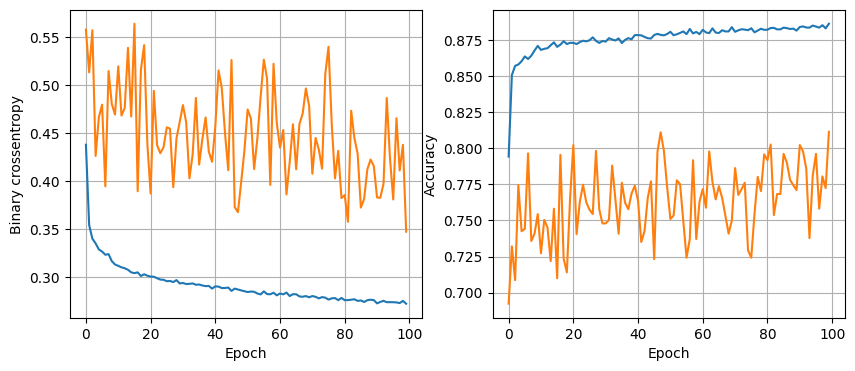

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8586 - loss: 0.3402
16 nodes, dropout 0, lr 0.005, batch size 128


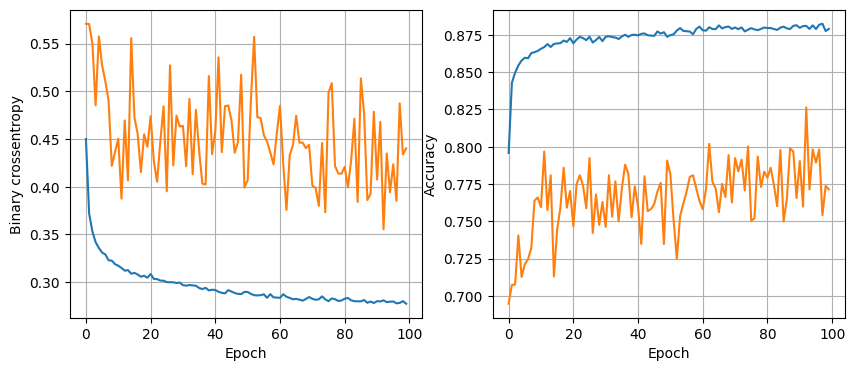

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3326
16 nodes, dropout 0, lr 0.001, batch size 32


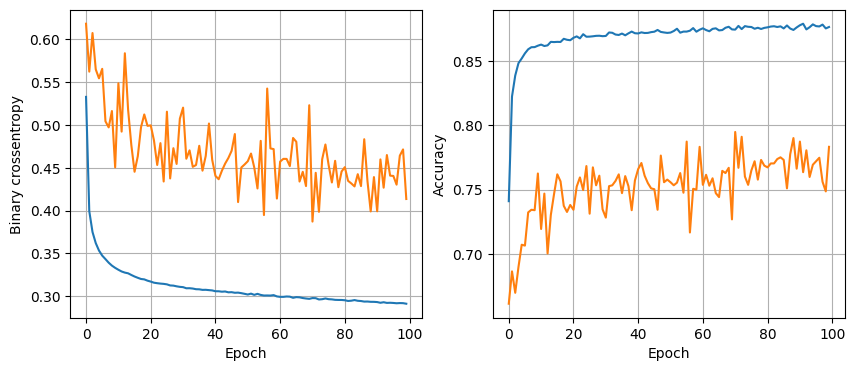

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8712 - loss: 0.3214
16 nodes, dropout 0, lr 0.001, batch size 64


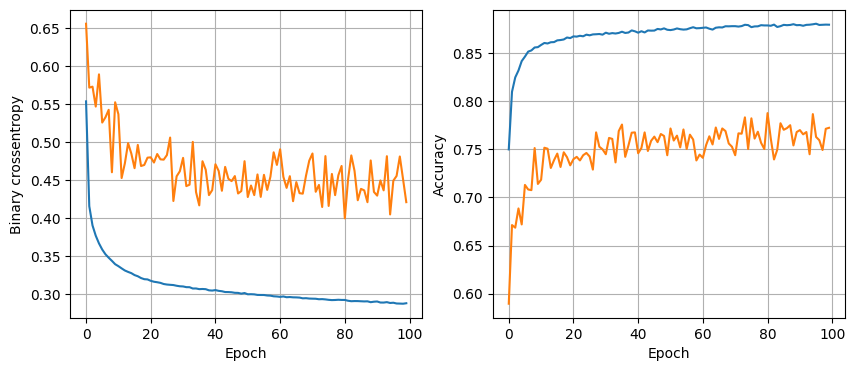

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.3210
16 nodes, dropout 0, lr 0.001, batch size 128


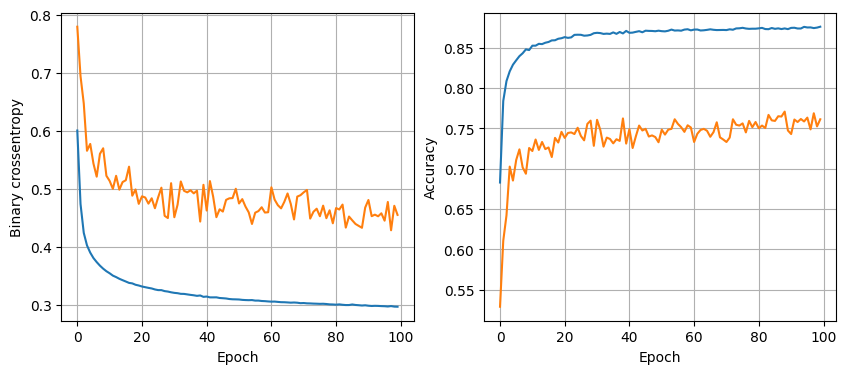

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8665 - loss: 0.3269
16 nodes, dropout 0.2, lr 0.01, batch size 32


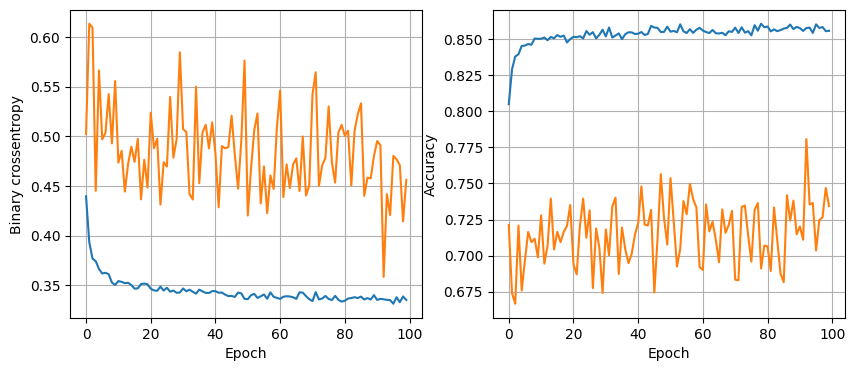

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8733 - loss: 0.3185
16 nodes, dropout 0.2, lr 0.01, batch size 64


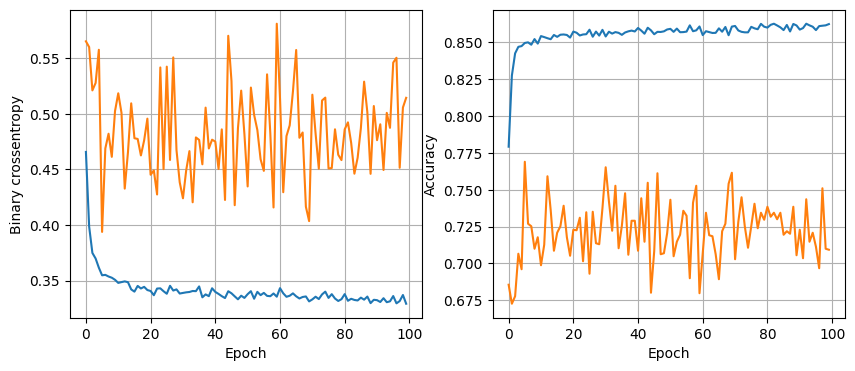

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3214
16 nodes, dropout 0.2, lr 0.01, batch size 128


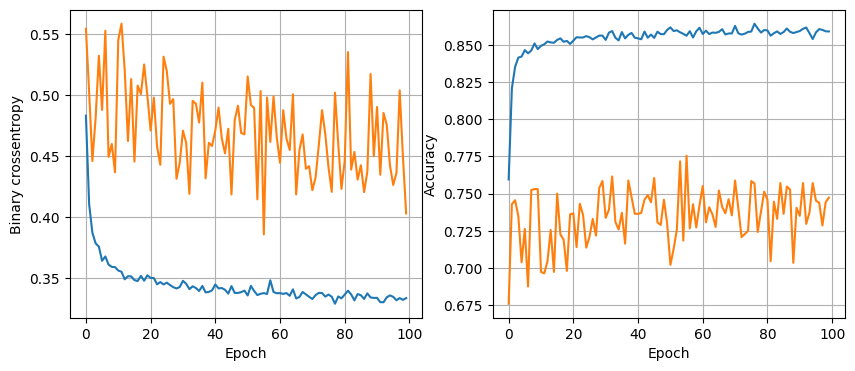

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8683 - loss: 0.3400
16 nodes, dropout 0.2, lr 0.005, batch size 32


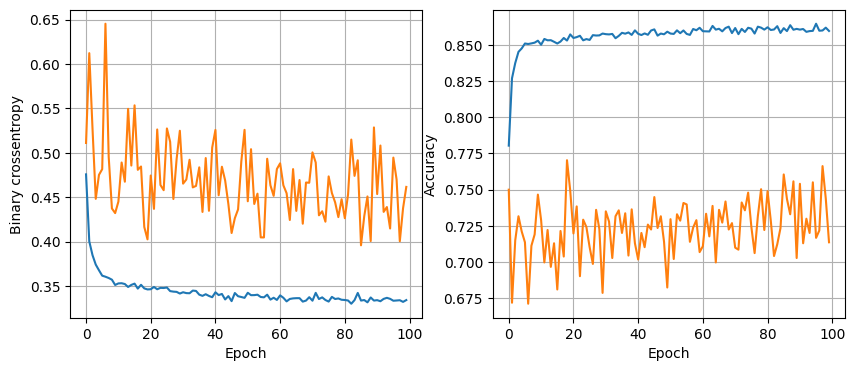

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3349
16 nodes, dropout 0.2, lr 0.005, batch size 64


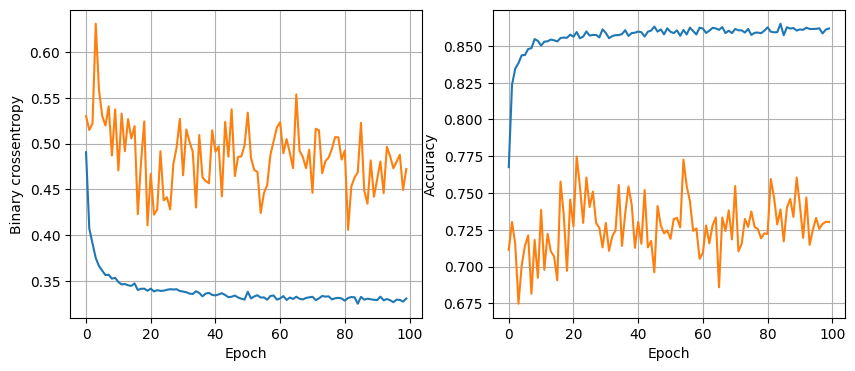

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3177
16 nodes, dropout 0.2, lr 0.005, batch size 128


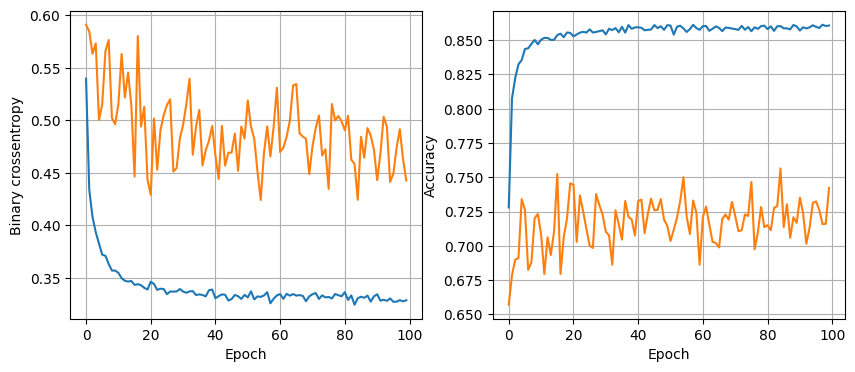

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8651 - loss: 0.3232
16 nodes, dropout 0.2, lr 0.001, batch size 32


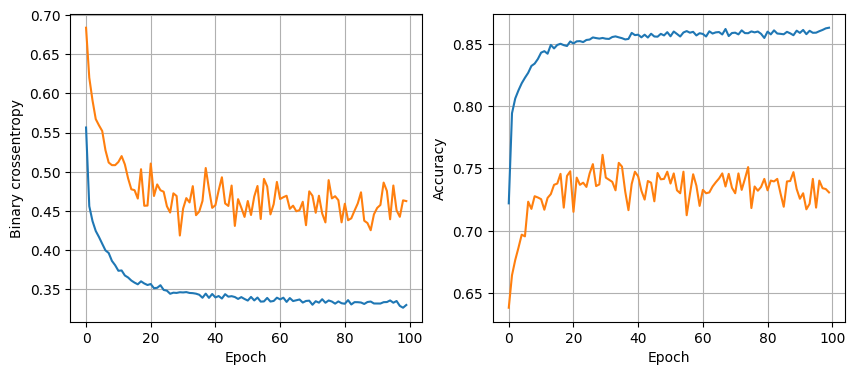

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8651 - loss: 0.3237
16 nodes, dropout 0.2, lr 0.001, batch size 64


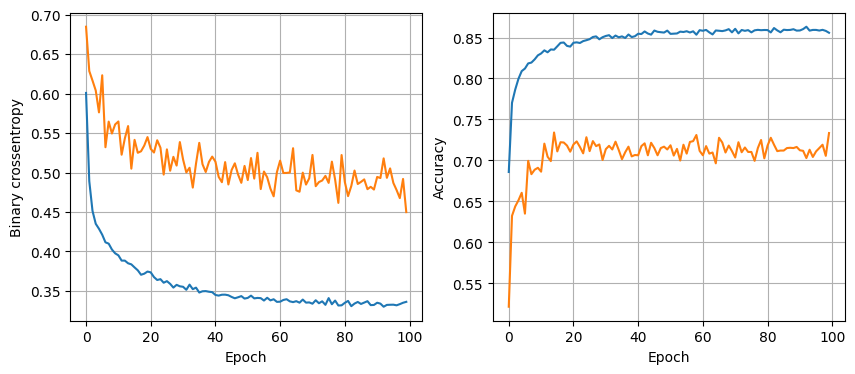

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3257
16 nodes, dropout 0.2, lr 0.001, batch size 128


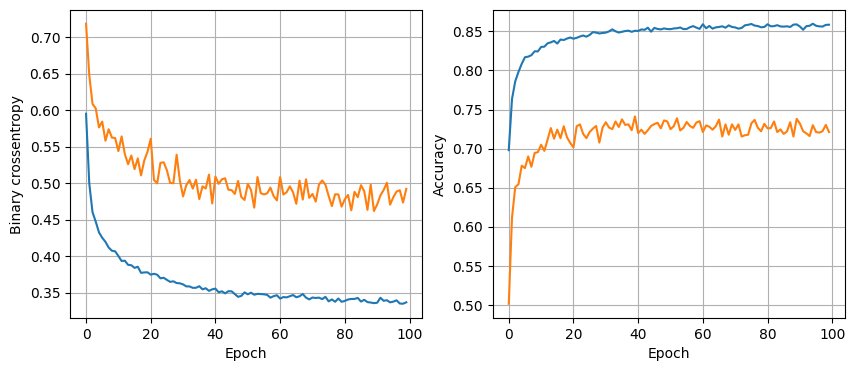

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3268
32 nodes, dropout 0, lr 0.01, batch size 32


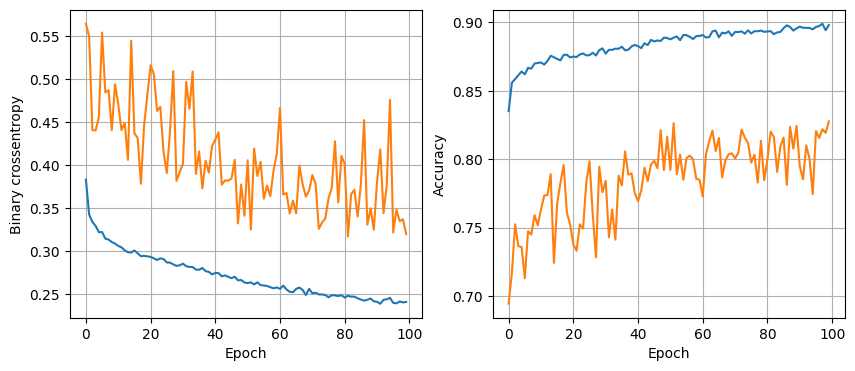

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8528 - loss: 0.4310
32 nodes, dropout 0, lr 0.01, batch size 64


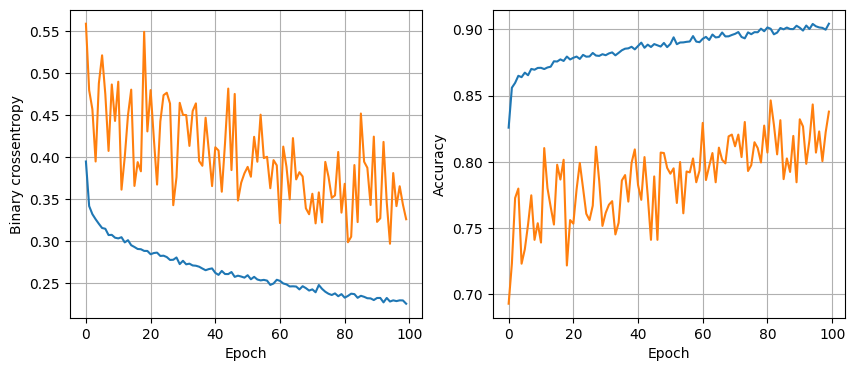

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8633 - loss: 0.3879
32 nodes, dropout 0, lr 0.01, batch size 128


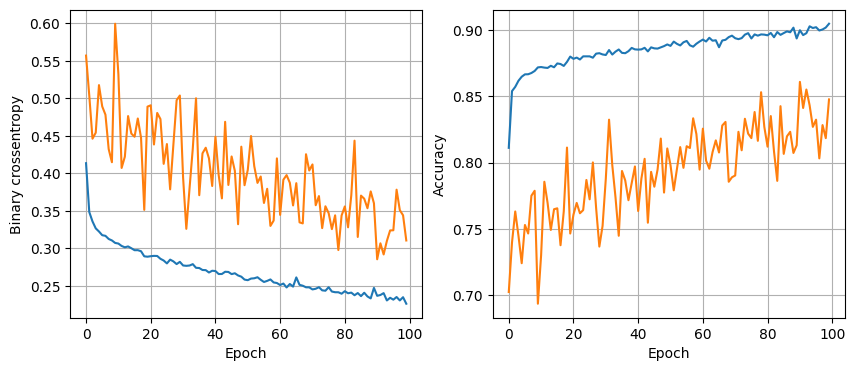

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8586 - loss: 0.4210
32 nodes, dropout 0, lr 0.005, batch size 32


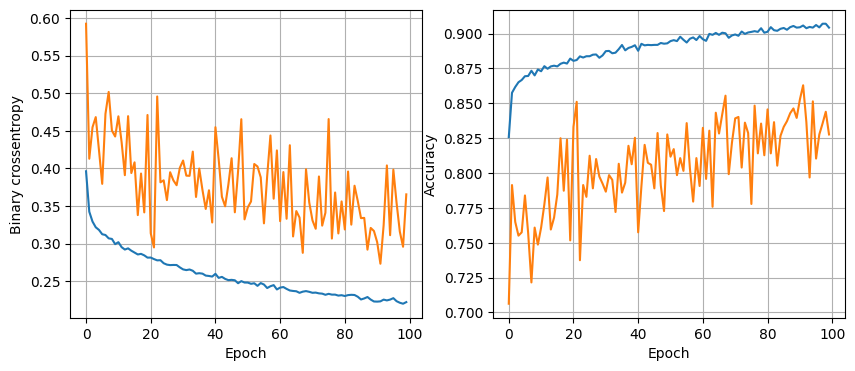

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8651 - loss: 0.3885
32 nodes, dropout 0, lr 0.005, batch size 64


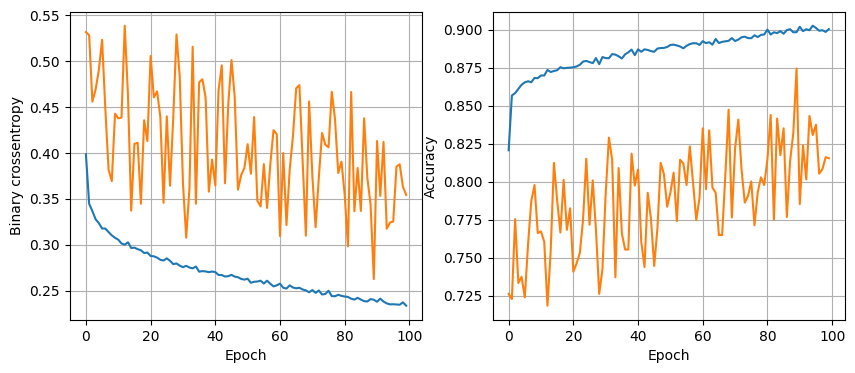

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8715 - loss: 0.3635
32 nodes, dropout 0, lr 0.005, batch size 128


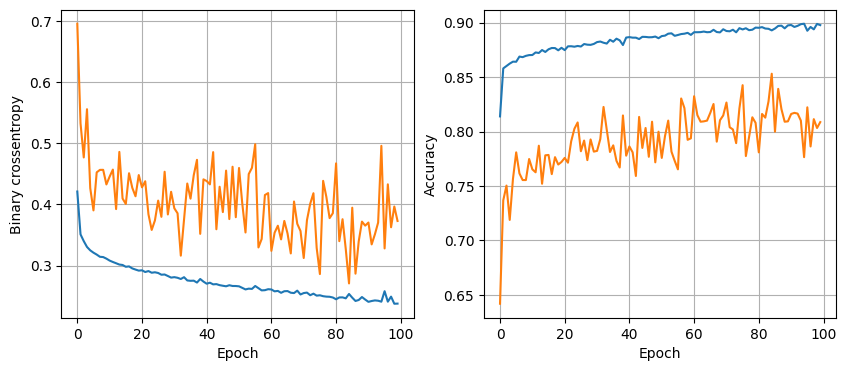

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8651 - loss: 0.3628
32 nodes, dropout 0, lr 0.001, batch size 32


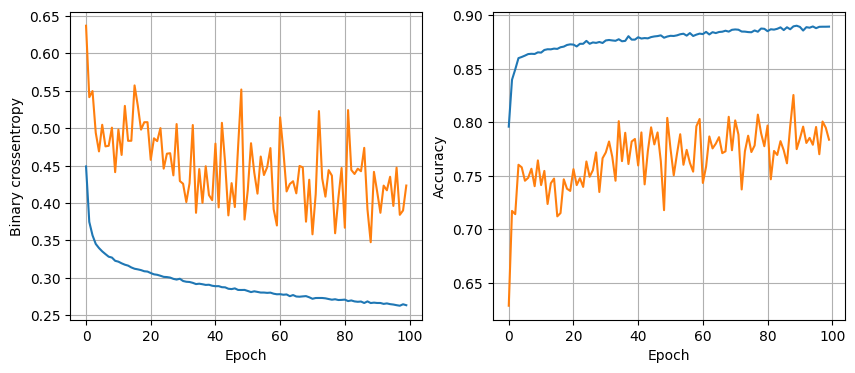

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.3329
32 nodes, dropout 0, lr 0.001, batch size 64


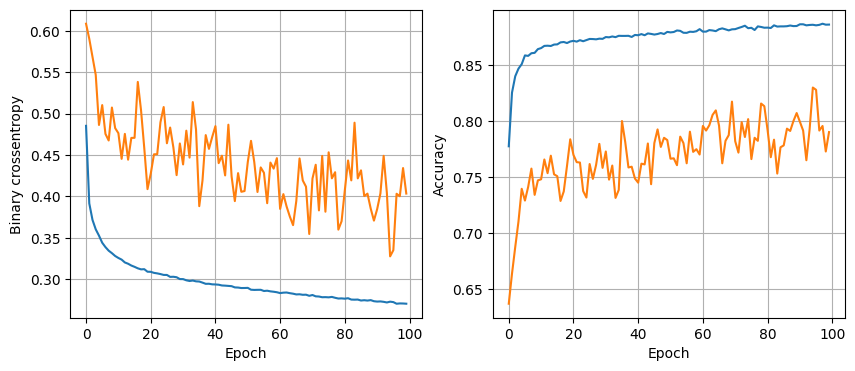

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3255
32 nodes, dropout 0, lr 0.001, batch size 128


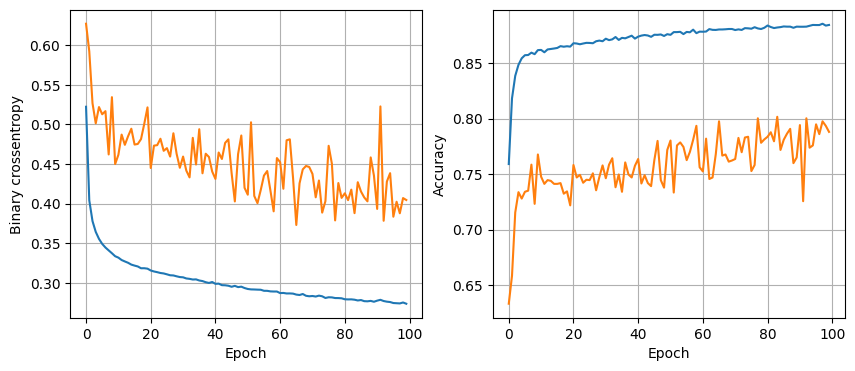

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3249
32 nodes, dropout 0.2, lr 0.01, batch size 32


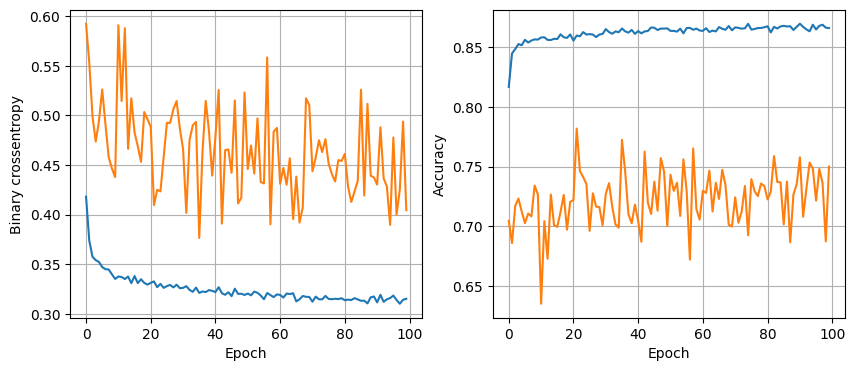

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8683 - loss: 0.3280
32 nodes, dropout 0.2, lr 0.01, batch size 64


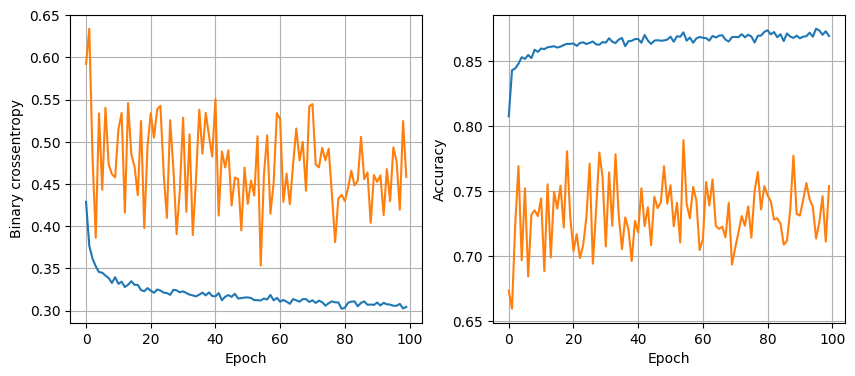

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8746 - loss: 0.3197
32 nodes, dropout 0.2, lr 0.01, batch size 128


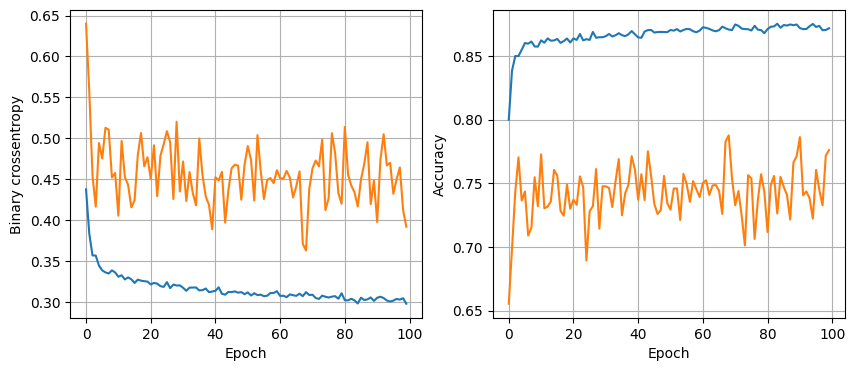

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3164
32 nodes, dropout 0.2, lr 0.005, batch size 32


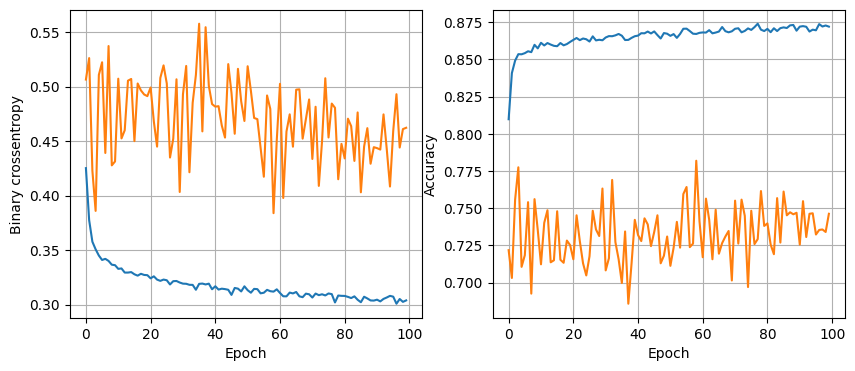

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8775 - loss: 0.3058
32 nodes, dropout 0.2, lr 0.005, batch size 64


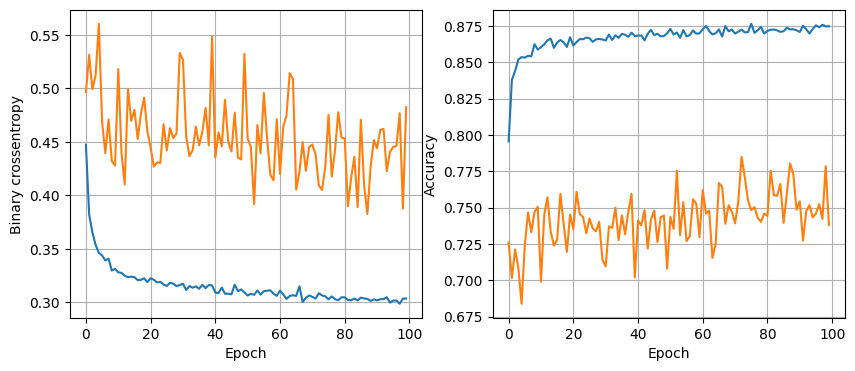

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3079
32 nodes, dropout 0.2, lr 0.005, batch size 128


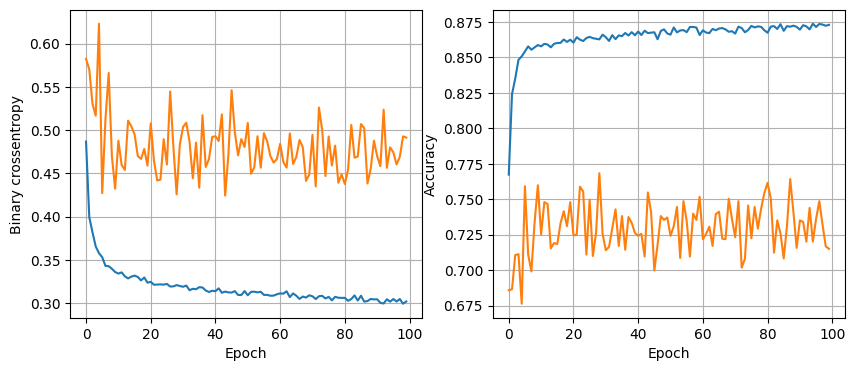

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8699 - loss: 0.3105
32 nodes, dropout 0.2, lr 0.001, batch size 32


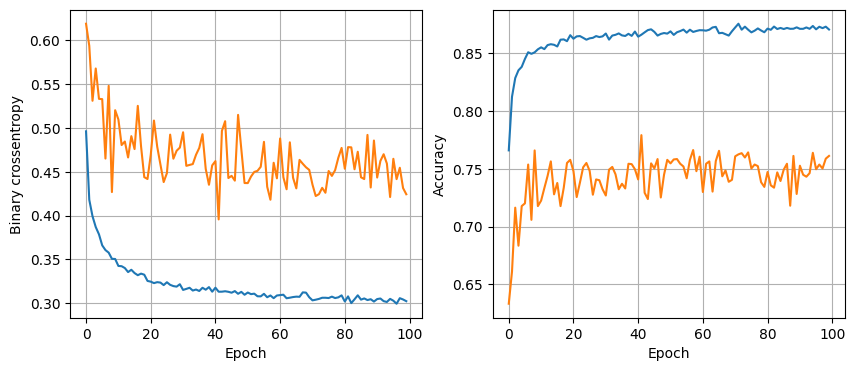

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3106
32 nodes, dropout 0.2, lr 0.001, batch size 64


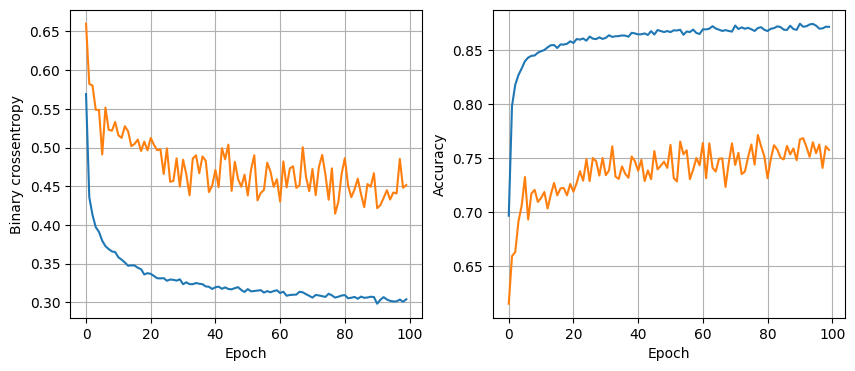

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3087
32 nodes, dropout 0.2, lr 0.001, batch size 128


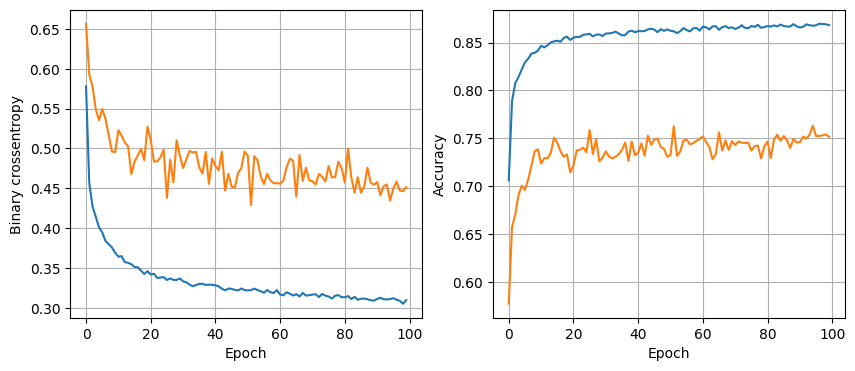

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.3137
64 nodes, dropout 0, lr 0.01, batch size 32


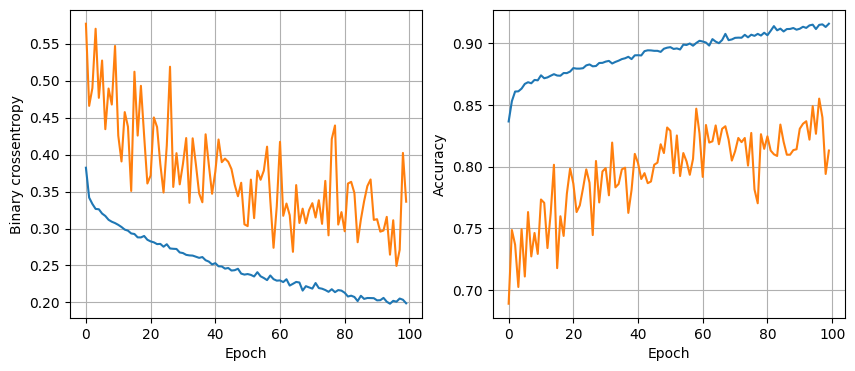

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.5386
64 nodes, dropout 0, lr 0.01, batch size 64


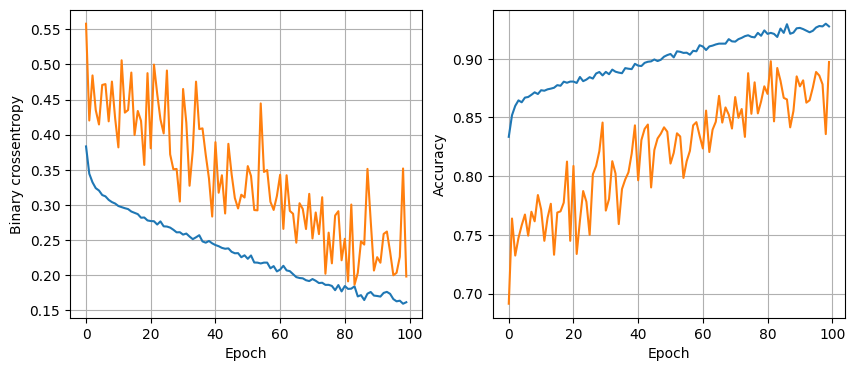

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8470 - loss: 0.6639
64 nodes, dropout 0, lr 0.01, batch size 128


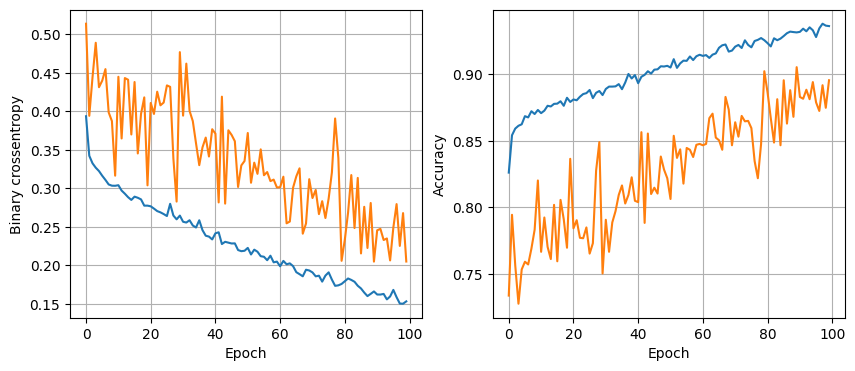

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.6007
64 nodes, dropout 0, lr 0.005, batch size 32


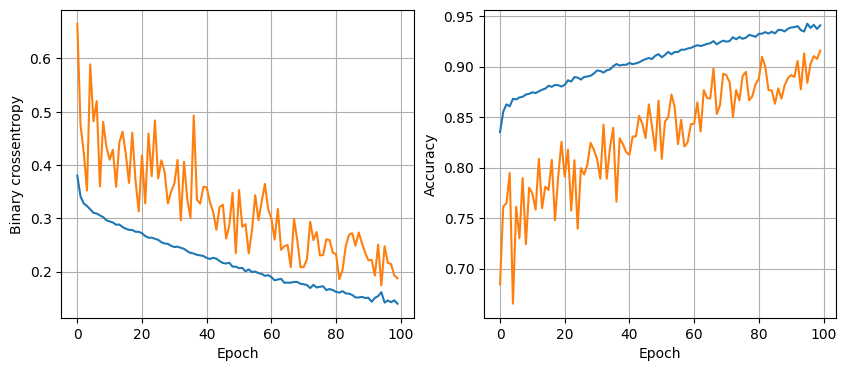

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8467 - loss: 0.7396
64 nodes, dropout 0, lr 0.005, batch size 64


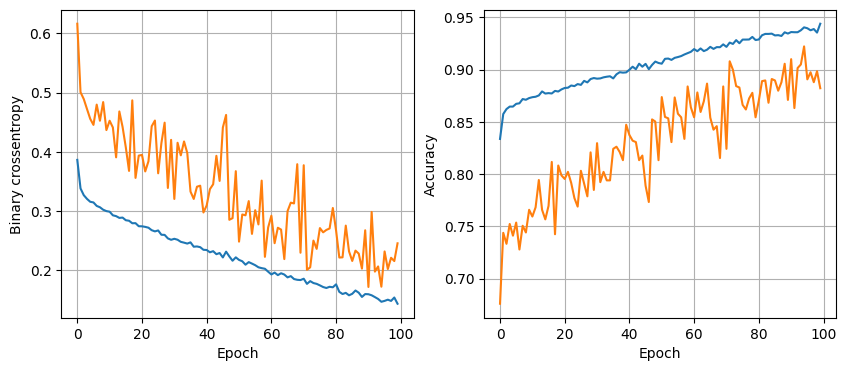

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.5811
64 nodes, dropout 0, lr 0.005, batch size 128


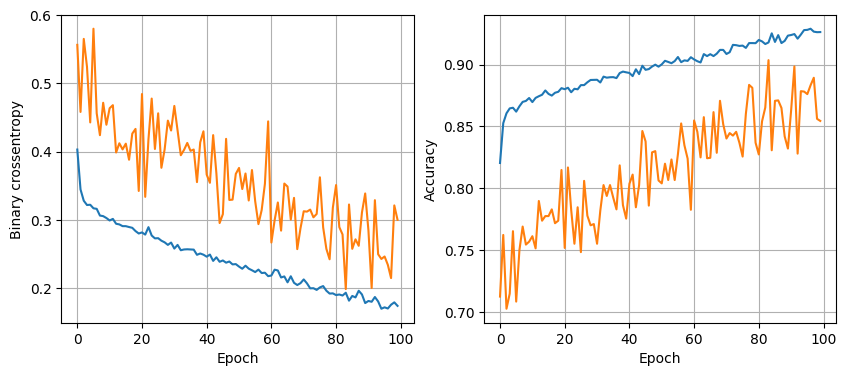

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.4606
64 nodes, dropout 0, lr 0.001, batch size 32


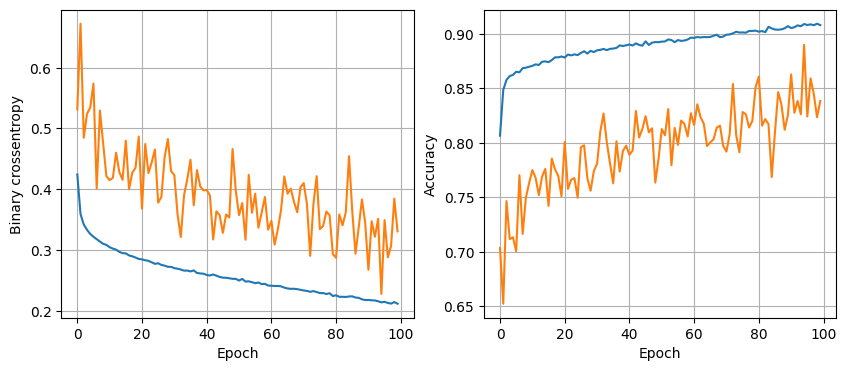

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3688
64 nodes, dropout 0, lr 0.001, batch size 64


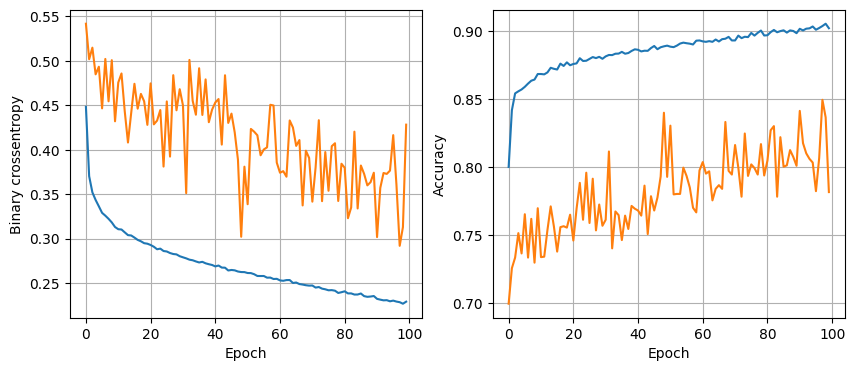

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8738 - loss: 0.3457
64 nodes, dropout 0, lr 0.001, batch size 128


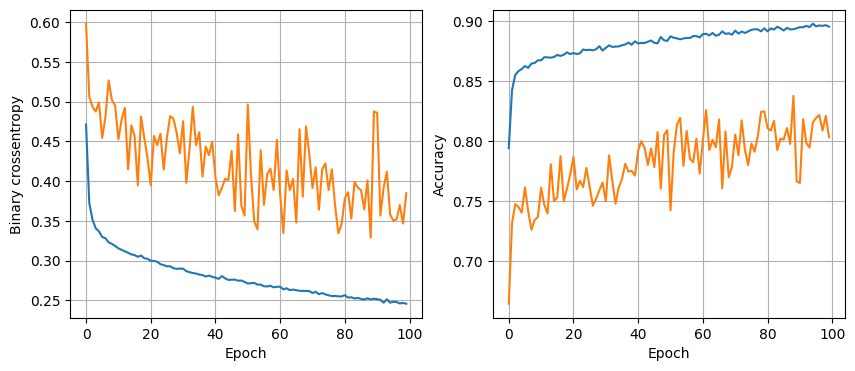

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3291
64 nodes, dropout 0.2, lr 0.01, batch size 32


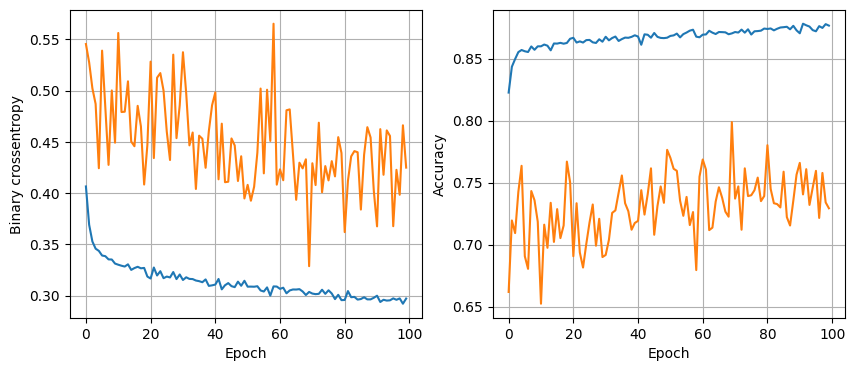

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8764 - loss: 0.3318
64 nodes, dropout 0.2, lr 0.01, batch size 64


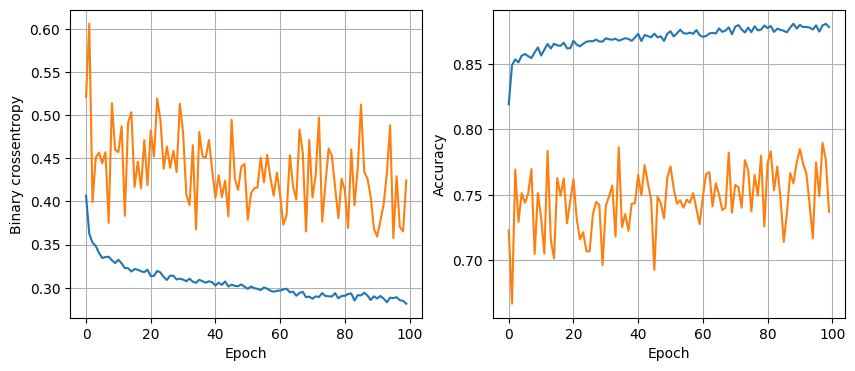

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8730 - loss: 0.3203
64 nodes, dropout 0.2, lr 0.01, batch size 128


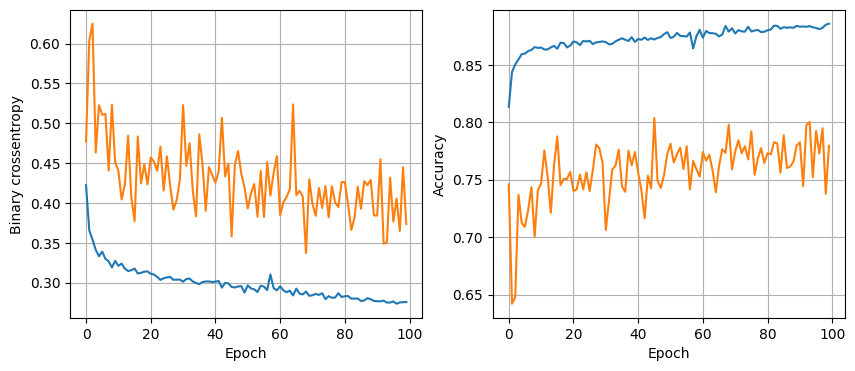

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8746 - loss: 0.3137
64 nodes, dropout 0.2, lr 0.005, batch size 32


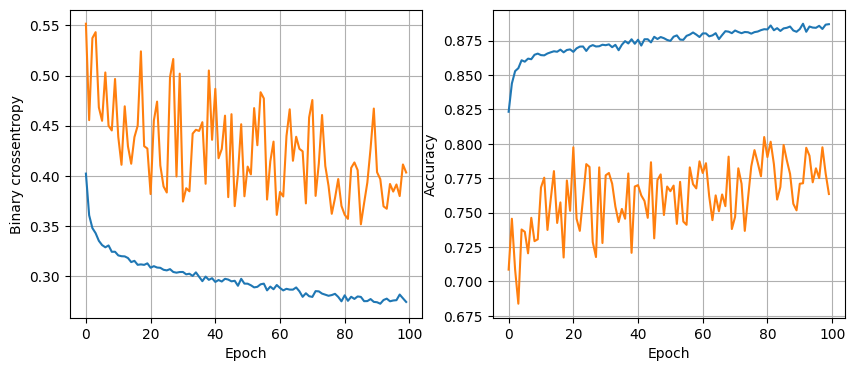

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8751 - loss: 0.3228
64 nodes, dropout 0.2, lr 0.005, batch size 64


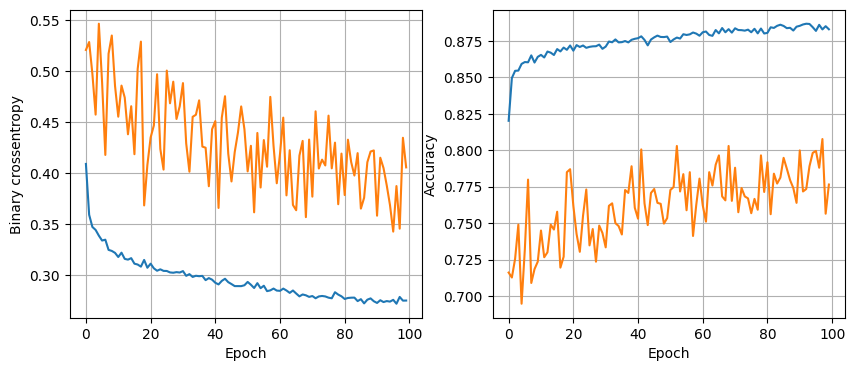

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3116
64 nodes, dropout 0.2, lr 0.005, batch size 128


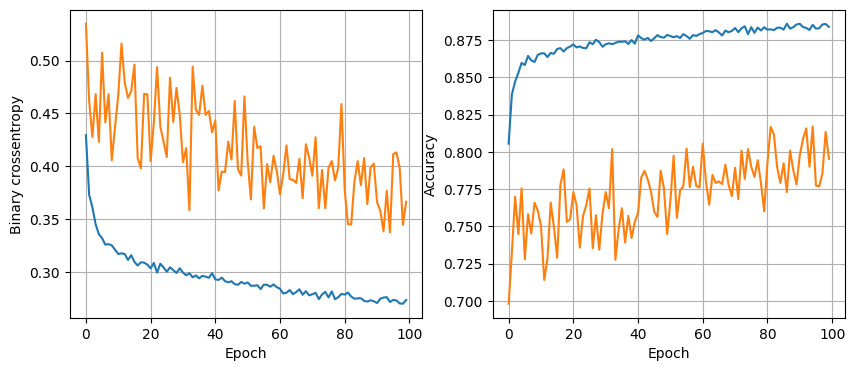

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8751 - loss: 0.3087
64 nodes, dropout 0.2, lr 0.001, batch size 32


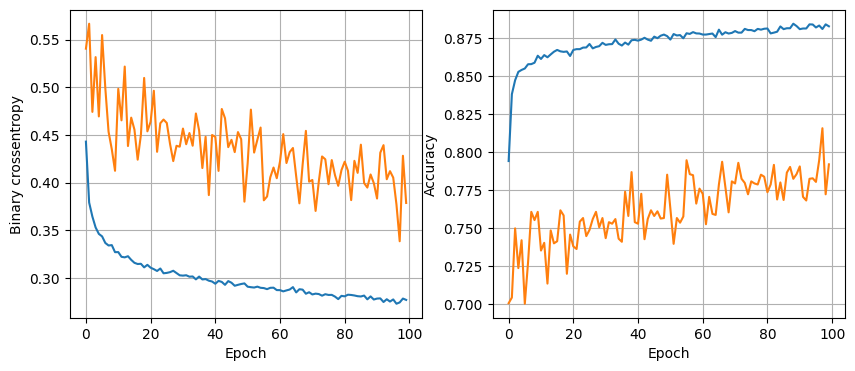

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8743 - loss: 0.3084
64 nodes, dropout 0.2, lr 0.001, batch size 64


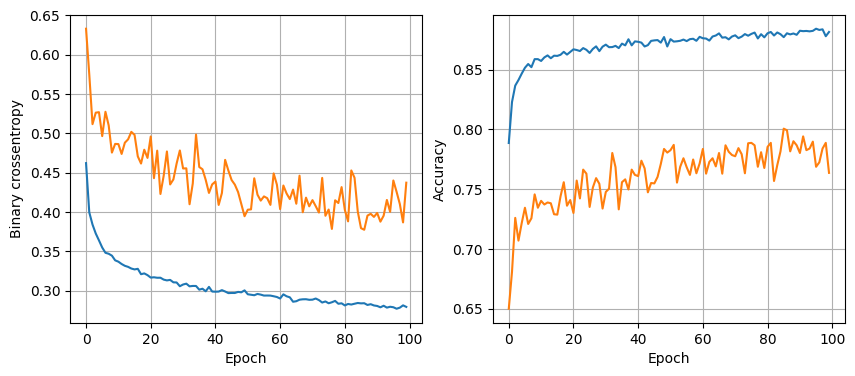

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8775 - loss: 0.3107
64 nodes, dropout 0.2, lr 0.001, batch size 128


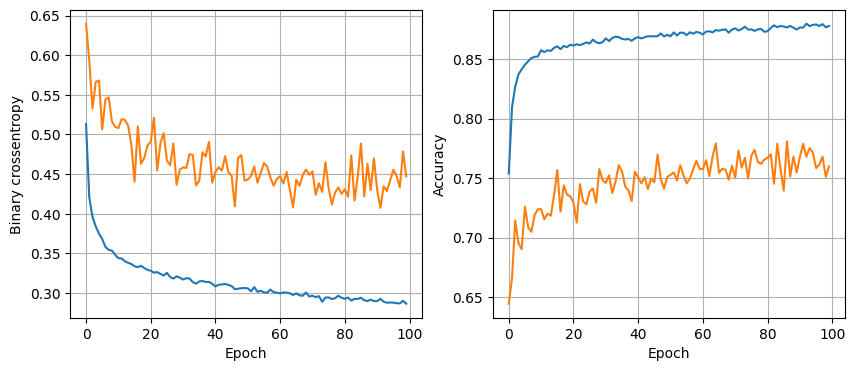

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8733 - loss: 0.3126


In [49]:
least_val_loss = float('inf')
least_loss_model = None
epochs=100
for num_nodes in [16, 32, 64]:
  for dropout_prob in[0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}")
        model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)
        val_loss = model.evaluate(X_valid, y_valid)[0]
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

In [50]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.73      0.80      1360
           1       0.86      0.95      0.90      2444

    accuracy                           0.87      3804
   macro avg       0.87      0.84      0.85      3804
weighted avg       0.87      0.87      0.87      3804

